In [14]:
import pandas as pd
import os
import numpy as np
import smarts_cerebellum.globals as gl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scripts.piecewise_linear_SI import piecewise_lin_pred

# DTI metrics
dti = pd.read_csv(os.path.join(gl.baseDir, 'DTI', 'JHU_MNI_DTI_flip.tsv'), sep = '\t')
dti = dti[dti.isPatient == 1] # just patients

# behavioural residuals
residuals_week = pd.read_csv(os.path.join(gl.baseDir, 'behavioural', 'piecewise_SI_residuals_week.tsv'), sep = '\t')
residuals_time_invariant = pd.read_csv(os.path.join(gl.baseDir, 'behavioural', 'piecewise_SI_residuals_time_invariant.tsv'), sep = '\t')


# behavioural metrics
behav = pd.read_csv(os.path.join(gl.baseDir, 'behavioural', 'summary_paretic.dat'), sep = '\t')
behav.rename(columns = {'subj_name': 'subj_id', 'week': 'Week'}, inplace = True)
behav['subj_id'] = behav['subj_id'].str.strip()
behav.loc[behav['Week']==1, 'Week'] = 0


/localscratch/tmp/ipykernel_12863/2766583303.py:11: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  dti = pd.read_csv(os.path.join(gl.baseDir, 'DTI', 'JHU_MNI_DTI_flip.tsv'), sep = '\t')


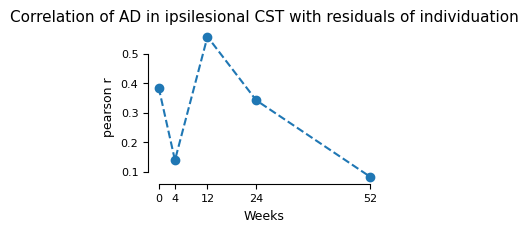

In [43]:
# correlate residuals (individuation) with dti metrics (AD, RD)
metric = 'lambda_1'
df = pd.merge(residuals_week, dti, on = ['subj_id', 'Week'])
df = df[(df.regionname == 'CST_R') & (df.metric == metric)]

rows = []
for week in gl.weeks:
    df_week = df[df.Week == week]
    r, p = stats.pearsonr(df_week['mean'], df_week['residuals'])
    rows.append({'Week': week, 'metric': metric, 'r': r, 'p': p})
corr_df = pd.DataFrame(rows)

# plot correlation values for each residual
fig, ax = plt.subplots(figsize = (3, 2))
ax.plot(corr_df['Week'], corr_df['r'], linestyle = '--', marker = 'o')

ax.set_xticks(gl.weeks)
ax.set_xlabel("Weeks")
ax.set_ylabel("pearson r")
#ax.set_ylim(0, 1)
plt.title("Correlation of AD in ipsilesional CST with residuals of individuation")

sns.despine(trim = True)
plt.show()

The next thing we want to look at are the residuals. So Jing fitted a piecewise function to the plot of strength against individuation (for each time point, and for all time points together). There is some amount of variance that is explained by this line; there is also unexplained variance in the data (model did not explain this). So this would be the difference between the observed value (y_obs = individuation) and the fitted value (y_hat) from the model.

This piecewise function explains some amount of the variance: strength (x) explains some amount of the variance in individuation (y) (up to about 60% recovery of strength). So the measure we have for individuation is partly explained by strength. Now, we are interested in the portion that is *not* explained by strength - this is the residual. The residuals are (I think) higher for the latter portion of the piecewise function. So there is a greater amount of recovery in individuation that is not explained by strength (though does it really recover here?), meaning we are interested in seeing what else could explain this individuation.

We should consider that the experimental measure for strength and individuation measure compared to FMH - what does FMH cover that is not covered by our experimental measures?

# Jing's plots

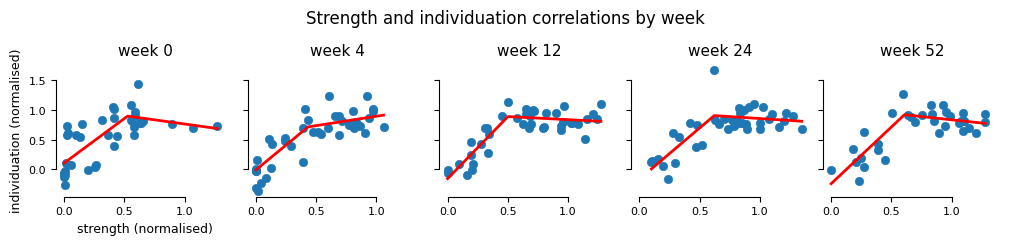

In [5]:
# plot behavioural strength v individuation, and add the curvilinear function (for each week)

fig, axs = plt.subplots(1, 5, figsize = (10,2), sharex = True, sharey = True, constrained_layout = True)
for i, week in enumerate(gl.weeks):

    # get line for each week
    behav_week = behav[behav.Week == week]
    x = (behav_week['mvc_norm'])
    y = (behav_week['indiv_norm'])

    res_for_week = residuals_week[residuals_week.Week == week]
    params = res_for_week[['x_star', 'beta_0', 'beta_1', 'beta_2']].drop_duplicates().values[0]

    ax = axs[i]
    sns.scatterplot(x = 'mvc_norm', y = 'indiv_norm', data = behav[behav.Week == week], ax = ax, edgecolor = None)
    sns.despine(trim = True)

    # plot piecewise regression line
    x_grid = np.linspace(x.min(), x.max(), 200)
    y_grid = piecewise_lin_pred(x_grid, params) # makes the line for each week
    ax.plot(x_grid, y_grid, color='red', lw=2)

    ax.set_ylabel('')
    ax.set_xlabel('')
    #ax.set_xticks([])
    ax.set_title(f'week {week}')
    

axs[0].set_ylabel("individuation (normalised)")
axs[0].set_xlabel("strength (normalised)")

fig.suptitle("Strength and individuation correlations by week", y = 1.15)
plt.show()


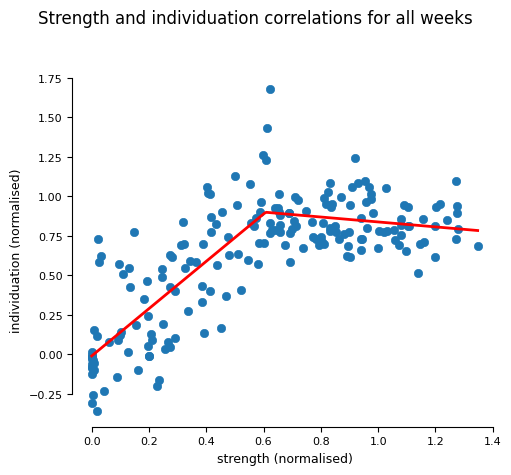

In [8]:
fig, ax = plt.subplots(figsize = (5, 4), sharex = True, sharey = True, constrained_layout = True)

# get line for each week
x = (behav['mvc_norm'])
y = (behav['indiv_norm'])

params = residuals_time_invariant[['x_star', 'beta_0', 'beta_1', 'beta_2']].drop_duplicates().values[0]

sns.scatterplot(x = 'mvc_norm', y = 'indiv_norm', data = behav, ax = ax, edgecolor = None)
sns.despine(trim = True)

# plot piecewise regression line
x_grid = np.linspace(x.min(), x.max(), 200)
y_grid = piecewise_lin_pred(x_grid, params)
ax.plot(x_grid, y_grid, color='red', lw=2)
    

ax.set_ylabel("individuation (normalised)")
ax.set_xlabel("strength (normalised)")

fig.suptitle("Strength and individuation correlations for all weeks", y = 1.15)
plt.show()
